# 综合题 · GAN 生成手写数字（面试专题）

> 题型：**动手实践**——用生成对抗网络（GAN）生成 MNIST 手写数字。
> 前置：只需 MLP（ch04）+ 训练循环（ch03）+ detach（ch02），不需要 CNN。
> 做完对照 `solutions/综合题-答案.md`。

## 目标

训练一个 GAN：**生成器 G** 从随机噪声生成假的手写数字，**判别器 D** 区分真假，两者对抗博弈，最终 G 能生成以假乱真的数字。

## 流程

① 定义 G（噪声 → 图片）→ ② 定义 D（图片 → 真/假）→ ③ 交替训练（含 detach）→ ④ 可视化生成结果

In [2]:
%matplotlib inline
import torch
from torch import nn
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('设备:', device)

# 加载 MNIST，归一化到 [-1, 1]（配合生成器的 Tanh 输出）
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # [0,1] -> [-1,1]
])
mnist = torchvision.datasets.MNIST(root='../data', train=True, transform=transform, download=True)
data_iter = data.DataLoader(mnist, batch_size=128, shuffle=True)
print('MNIST 加载完成，批数:', len(data_iter))

设备: cuda
MNIST 加载完成，批数: 469


## 第一步 · 定义生成器 G（TODO 1）

G 把 100 维随机噪声映射成 784 维（28×28）图片。

- 结构：Linear(100→256) → ReLU → Linear(256→512) → ReLU → Linear(512→784) → **Tanh**
- 最后一层用 Tanh，因为图片归一化到了 [-1, 1]
- 提示：`nn.Sequential` 一行写完

In [3]:
z_dim = 100   # 噪声维度

def make_generator():
    # TODO 1: 噪声(100) -> 图片(784)，最后一层 Tanh
    return nn.Sequential(nn.Linear(100, 256),
                         nn.ReLU(),
                         nn.Linear(256, 512),
                         nn.ReLU(),
                         nn.Linear(512, 784),
                         nn.Tanh())
                         

# ---- 自测：完成 TODO 1 后运行 ----
try:
    G = make_generator()
    z = torch.randn(2, z_dim)
    out = G(z)
    assert out.shape == (2, 784), f'形状 {out.shape} 不对，期望 (2, 784)'
    print('✓ G 输出形状正确:', list(out.shape))
except NotImplementedError as e:
    print(f'⚠ {e}')

✓ G 输出形状正确: [2, 784]


## 第二步 · 定义判别器 D（TODO 2）

D 把 784 维图片映射成 1 个概率（真=1，假=0）。

- 结构：Linear(784→512) → LeakyReLU → Linear(512→256) → LeakyReLU → Linear(256→1) → **Sigmoid**
- 最后一层 Sigmoid，输出 (0,1) 的概率
- `nn.LeakyReLU(0.2)`（GAN 里常用，比 ReLU 好，避免死神经元）

In [4]:
def make_discriminator():
    # TODO 2: 图片(784) -> 真/假概率(1)，最后一层 Sigmoid
    return nn.Sequential(nn.Linear(784, 512),
                         nn.LeakyReLU(0.2),
                         nn.Linear(512, 256),
                         nn.LeakyReLU(0.2),
                         nn.Linear(256, 1),
                         nn.Sigmoid())
                         

# ---- 自测：完成 TODO 2 后运行 ----
try:
    D = make_discriminator()
    img = torch.randn(2, 784)
    out = D(img)
    assert out.shape == (2, 1), f'形状 {out.shape} 不对，期望 (2, 1)'
    assert ((out > 0) & (out < 1)).all(), 'Sigmoid 输出应在 (0,1) 之间'
    print('✓ D 输出形状正确:', list(out.shape))
except NotImplementedError as e:
    print(f'⚠ {e}')

✓ D 输出形状正确: [2, 1]


## 第三步 · 交替训练（TODO 3，最关键）

每个 batch 做两件事：

**① 训 D（固定 G）**：真实样本 label=1，G 生成的假样本 label=0。注意假样本要 `.detach()`（截断梯度，别流回 G）。

**② 训 G（固定 D）**：假样本 label=1（骗 D）。这里**不 detach**，让梯度穿过 D 反传给 G。

损失用 `nn.BCELoss()`（二分类交叉熵）。

In [6]:
def train_gan(G, D, data_iter, num_epochs=50, lr=0.0002):
    G.to(device); D.to(device)
    loss = nn.BCELoss()
    opt_G = torch.optim.Adam(G.parameters(), lr=lr)
    opt_D = torch.optim.Adam(D.parameters(), lr=lr)

    for epoch in range(num_epochs):
        for X, _ in data_iter:
            X = X.view(X.size(0), -1).to(device)   # (batch,1,28,28) -> (batch,784)
            batch = X.size(0)
            real_label = torch.ones(batch, 1).to(device)
            fake_label = torch.zeros(batch, 1).to(device)

            # ---- ① 训 D（固定 G）----
            z = torch.randn(batch, z_dim).to(device)
            fake = G(z)
            # TODO 3a: 算 loss_D = 真实样本判1的loss + 假样本判0的loss
            #          真实: loss(D(X), real_label)；假样本: loss(D(fake.detach()), fake_label)
            #          （假样本 .detach() 防止梯度回流 G）
            fake_loss = loss(D(fake.detach()), fake_label)
            real_loss = loss(D(X), real_label)
            loss_D = fake_loss + real_loss
            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()
            # ---- ② 训 G（固定 D）----
            z = torch.randn(batch, z_dim).to(device)
            fake = G(z)
            # TODO 3b: 算 loss_G = 假样本判1的loss（骗过 D）
            #          注意：这里【不 detach】，梯度要穿过 D 反传给 G
            loss_G = loss(D(fake), real_label)
            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

        if (epoch + 1) % 10 == 0:
            print(f'epoch {epoch+1}')
    return G, D


## 第四步 · 训练 + 可视化生成结果

epoch 10
epoch 20
epoch 30
epoch 40
epoch 50
epoch 60
epoch 70


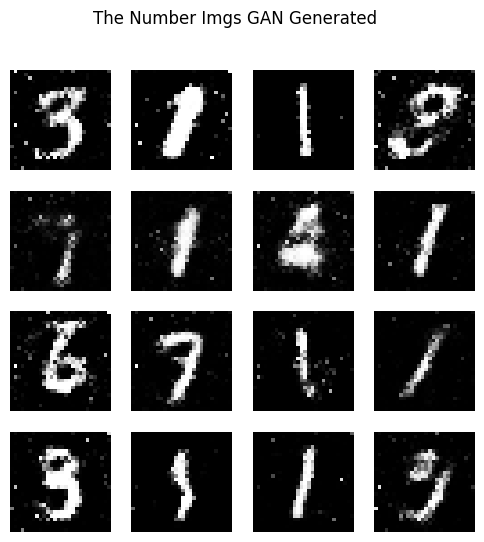

In [9]:
try:
    G = make_generator()
    D = make_discriminator()
    train_gan(G, D, data_iter, num_epochs=70)
except NotImplementedError as e:
    print(f'⚠ {e}，先完成前面所有 TODO 再运行本 cell')
else:
    # 生成一批假图片，可视化
    G.eval()
    with torch.no_grad():
        z = torch.randn(16, z_dim).to(device)
        fake = G(z).cpu().view(16, 28, 28)

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake[i], cmap='gray')
        ax.axis('off')
    plt.suptitle('The Number Imgs GAN Generated')
    plt.show()


## 面试衔接（做完后能回答）

1. GAN 的核心思想是什么？两个网络分别是什么角色？
2. 训练时为什么要「交替」更新 G 和 D？
3. 训 D 时为什么对 G 的输出 `.detach()`？训 G 时为什么不 detach？

- **训 D**：`D(fake.detach())`——detach 让 G 的输出当常数，梯度不流回 G（因为这一步只更新 D）。
- **训 G**：`D(fake)` 不 detach——G 的梯度需要**穿过 D 反传**回来（G 靠 D 的反馈学习）。
- **loss_G 用 `real_label`**：G 想让 D 把假样本判成 1（骗过 D），所以 label 是 1，不是 0。

4. loss_G 为什么用 `BCE(D(fake), 1)` 而不是 `BCE(D(fake), 0)`？